**Egyptian Currency CNN Classifier — 2023 Banknotes**

**Dataset:** `belalsafy/egyptian-new-currency-2023` (Kaggle)  
**Classes (9):** `1`, `5`, `10`, `10_new`, `20`, `20_new`, `50`, `100`, `200` EGP  

```
dataset/
├── train/   (2,927 images)
│   ├── 1/   5/   10/   10_new/   20/   20_new/   50/   100/   200/
└── test/    (760 images)
    └── (same 9 sub-folders)
```


## 1. Imports & Setup

In [1]:
import os, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image as PILImage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cpu')
print(f'Device : {DEVICE}')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_ROOT = 'data_raw//dataset'
TRAIN_DIR    = os.path.join(DATASET_ROOT, 'train')  # 2,927 images
TEST_DIR     = os.path.join(DATASET_ROOT, 'test')   # 760 images (was valid/)
CKPT_PATH    = 'best_model.pth'

# ── Hyper-parameters ──────────────────────────────────────────────────────────
IMG_SIZE    = 128
BATCH_SIZE  = 32
NUM_EPOCHS  = 100
LR          = 5e-4

FOLDER_NAMES = ['1', '5', '10', '10_new', '20', '20_new', '50', '100', '200']
NUM_CLASSES  = len(FOLDER_NAMES)  # 9

DISPLAY_LABELS = {
    '1'      : '1 EGP',
    '5'      : '5 EGP',
    '10'     : '10 EGP (old)',
    '10_new' : '10 EGP (new)',
    '20'     : '20 EGP (old)',
    '20_new' : '20 EGP (new)',
    '50'     : '50 EGP',
    '100'    : '100 EGP',
    '200'    : '200 EGP',
}

print(f'Number of classes : {NUM_CLASSES}')
print(f'Classes           : {FOLDER_NAMES}')
print(f'Image size        : {IMG_SIZE}×{IMG_SIZE}')


Device : cpu
Number of classes : 9
Classes           : ['1', '5', '10', '10_new', '20', '20_new', '50', '100', '200']
Image size        : 128×128


---
## 2. Dataset Verification

In [2]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tiff'}

def count_images(split_dir):
    counts = {}
    if not os.path.isdir(split_dir):
        print(f'[WARN] Not found: {split_dir}')
        return counts
    for cls_folder in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls_folder)
        if not os.path.isdir(cls_path):
            continue
        n = sum(1 for f in os.listdir(cls_path)
                if os.path.splitext(f)[1].lower() in IMG_EXTS)
        counts[cls_folder] = n
    return counts

# Only two splits now — no valid/
splits     = {'train': TRAIN_DIR, 'test': TEST_DIR}
all_counts = {s: count_images(d) for s, d in splits.items()}
all_cls    = sorted(set(k for v in all_counts.values() for k in v))

header = f'{"Class":>14}' + ''.join(f'  {s:>7}' for s in splits) + f'  {"Total":>7}'
print(header)
print('─' * len(header))
grand_total = 0
for cls in all_cls:
    row_counts = [all_counts[s].get(cls, 0) for s in splits]
    row_total  = sum(row_counts)
    grand_total += row_total
    display = DISPLAY_LABELS.get(cls, cls)
    print(f'{display:>14}' + ''.join(f'  {c:>7}' for c in row_counts) + f'  {row_total:>7}')
print('─' * len(header))
split_totals = [sum(all_counts[s].values()) for s in splits]
print(f'{"TOTAL":>14}' + ''.join(f'  {t:>7}' for t in split_totals) + f'  {grand_total:>7}')

missing = [c for c in FOLDER_NAMES if c not in all_counts['train']]
if missing:
    print(f'\n[WARN] Missing in train/: {missing}')
else:
    print(f'\nAll {NUM_CLASSES} class folders present.')


         Class    train     test    Total
─────────────────────────────────────────
         1 EGP       80       20      100
  10 EGP (old)      350       80      430
       100 EGP      350       80      430
  10 EGP (new)      347      130      477
  20 EGP (old)      357       80      437
       200 EGP      348       80      428
  20 EGP (new)      376      130      506
         5 EGP      360       80      440
        50 EGP      350       80      430
─────────────────────────────────────────
         TOTAL     2918      760     3678

All 9 class folders present.


---
## 3. Data Loading & Augmentation Pipeline

In [3]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 8, IMG_SIZE + 8)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, scale=(0.85, 1.15), shear=5),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.10, scale=(0.02, 0.08)),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
test_ds  = datasets.ImageFolder(TEST_DIR,  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

IDX_TO_FOLDER   = {v: k for k, v in train_ds.class_to_idx.items()}
ORDERED_FOLDERS = [IDX_TO_FOLDER[i] for i in range(NUM_CLASSES)]
ORDERED_LABELS  = [DISPLAY_LABELS[f] for f in ORDERED_FOLDERS]

print('class_to_idx    :', train_ds.class_to_idx)
print('ORDERED_LABELS  :', ORDERED_LABELS)
print(f'\nTrain : {len(train_ds):,}  |  Test : {len(test_ds):,}')


class_to_idx    : {'1': 0, '10': 1, '100': 2, '10_new': 3, '20': 4, '200': 5, '20_new': 6, '5': 7, '50': 8}
ORDERED_LABELS  : ['1 EGP', '10 EGP (old)', '100 EGP', '10 EGP (new)', '20 EGP (old)', '200 EGP', '20 EGP (new)', '5 EGP', '50 EGP']

Train : 2,918  |  Test : 760


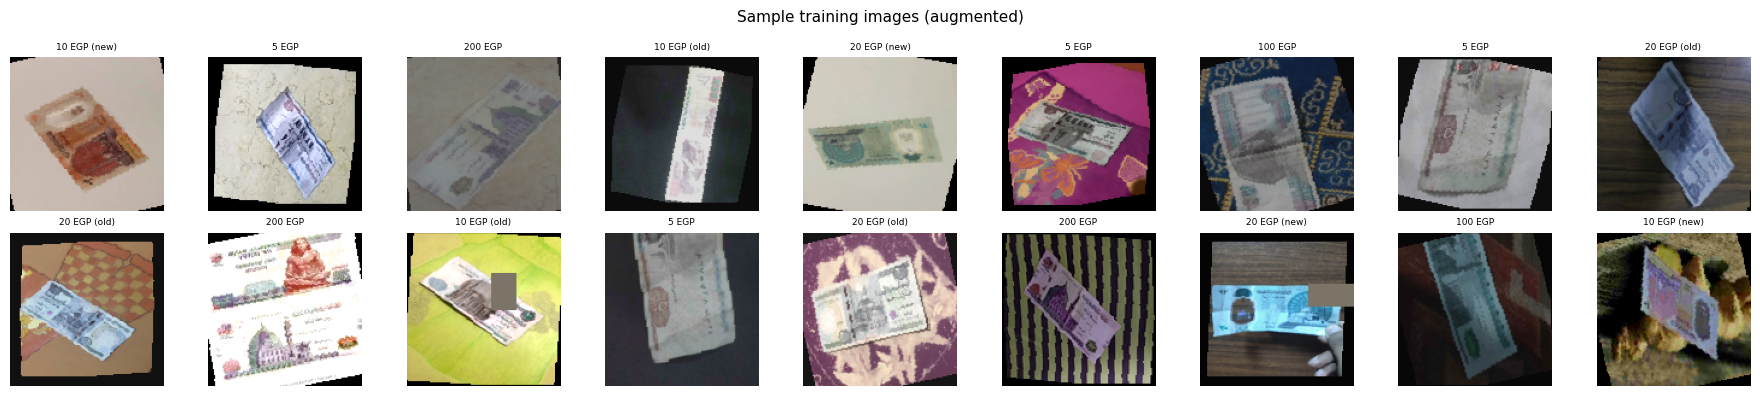

In [4]:
# Sample augmented training images
def denorm(tensor):
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(MEAN, STD)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

imgs, labels = next(iter(train_loader))
n_show = min(18, len(imgs))
fig, axes = plt.subplots(2, 9, figsize=(18, 4))
for i, ax in enumerate(axes.flatten()):
    if i >= n_show:
        ax.axis('off'); continue
    ax.imshow(denorm(imgs[i]).permute(1, 2, 0).numpy())
    ax.set_title(ORDERED_LABELS[labels[i].item()], fontsize=6.5)
    ax.axis('off')
plt.suptitle('Sample training images (augmented)', fontsize=11)
plt.tight_layout()
plt.show()    

---
## 4. Custom CNN Architecture

```
Input              [B,   3, 128, 128]
────────────────────────────────────────────────────────
Conv Block 1       [B,  32,  64,  64]   Conv(3×3)→BN→ReLU→MaxPool(2×2)
Conv Block 2       [B,  64,  32,  32]   Conv(3×3)→BN→ReLU→MaxPool(2×2)
Conv Block 3       [B, 128,  16,  16]   Conv(3×3)→BN→ReLU→MaxPool(2×2)
Conv Block 4       [B, 256,   8,   8]   Conv(3×3)→BN→ReLU→MaxPool(2×2)
Conv Block 5       [B, 512,   4,   4]   Conv(3×3)→BN→ReLU→MaxPool(2×2)
────────────────────────────────────────────────────────
AdaptiveAvgPool    [B, 512,   1,   1]
Flatten            [B, 512]
FC(512→256) + ReLU + Dropout(0.30)
FC(256→128) + ReLU + Dropout(0.20)
FC(128→9)   — logits (9 classes)
```

In [5]:
class ConvBlock(nn.Module):
    """Conv2D(3×3) → BatchNorm → ReLU → MaxPool(2×2)"""
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

    def forward(self, x):
        return self.block(x)


class EgyptianCurrencyCNN(nn.Module):
    """
    4-block custom CNN for Egyptian 2023 banknote classification.
    """
    def __init__(self, num_classes: int = 9):
        super().__init__()

        self.features = nn.Sequential(
            ConvBlock(3,    32),    # 64×64 → 32×32
            ConvBlock(32,   64),    # 32×32 → 16×16
            ConvBlock(64,  128),    # 16×16 →  8×8
            ConvBlock(128, 256),    #  8×8  →  4×4
        )

        self.gap = nn.AdaptiveAvgPool2d(1) 

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.40),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.30),
            nn.Linear(128, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x


model = EgyptianCurrencyCNN(num_classes=NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

# Sanity: forward pass
with torch.no_grad():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
    out   = model(dummy)
print(f'Output shape    : {tuple(out.shape)}   ← expected (2, {NUM_CLASSES})')

Total parameters: 488,745
Output shape    : (2, 9)   ← expected (2, 9)


---
## 5. Training Loop

In [6]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=4
)


def run_epoch(loader, is_train: bool):
    model.train() if is_train else model.eval()
    total_loss = correct = total = 0
    with torch.set_grad_enabled(is_train):
        for imgs, labels in loader:
            if is_train:
                optimizer.zero_grad()
            logits = model(imgs)
            loss   = criterion(logits, labels)
            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}
best_test_acc = 0.0
best_epoch    = 0

print(f'{"Ep":>4}  {"Tr Loss":>8}  {"Tr Acc%":>8}  {"Te Loss":>8}  {"Te Acc%":>8}  LR')
print('─' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, is_train=True)
    te_loss, te_acc = run_epoch(test_loader,  is_train=False)
    scheduler.step(te_acc)

    history['train_loss'].append(tr_loss)
    history['test_loss'].append(te_loss)
    history['train_acc'].append(tr_acc)
    history['test_acc'].append(te_acc)

    cur_lr = optimizer.param_groups[0]['lr']
    flag   = ''
    if te_acc > best_test_acc:
        best_test_acc = te_acc
        best_epoch    = epoch
        torch.save(model.state_dict(), CKPT_PATH)
        flag = '  ◀ best'

    print(f'{epoch:>4}  {tr_loss:>8.4f}  {tr_acc*100:>8.2f}  '
          f'{te_loss:>8.4f}  {te_acc*100:>8.2f}  {cur_lr:.2e}{flag}')

print(f'\nBest test accuracy: {best_test_acc*100:.2f}%  (epoch {best_epoch})')
print(f'Checkpoint: {CKPT_PATH}')


  Ep   Tr Loss   Tr Acc%   Te Loss   Te Acc%  LR
─────────────────────────────────────────────────────────────────
   1    2.3241     14.60    2.0389     23.29  5.00e-04  ◀ best
   2    2.0871     20.42    1.9714     25.53  5.00e-04  ◀ best
   3    2.0320     23.27    1.9013     29.61  5.00e-04  ◀ best
   4    1.9799     25.26    1.8854     31.05  5.00e-04  ◀ best
   5    1.9258     27.79    1.9846     26.71  5.00e-04
   6    1.8810     30.84    1.9273     26.18  5.00e-04
   7    1.8710     30.09    1.7336     38.68  5.00e-04  ◀ best
   8    1.8214     33.48    1.6329     42.89  5.00e-04  ◀ best
   9    1.7989     34.82    1.6324     42.76  5.00e-04
  10    1.7526     36.19    1.6332     43.29  5.00e-04  ◀ best
  11    1.7288     36.57    1.6328     44.34  5.00e-04  ◀ best
  12    1.6927     38.69    1.9137     36.45  5.00e-04
  13    1.6615     40.44    1.5301     48.82  5.00e-04  ◀ best
  14    1.6523     41.47    1.5546     48.42  5.00e-04
  15    1.6059     42.70    1.5031     50.6

---
## 6. Loss & Accuracy Curves

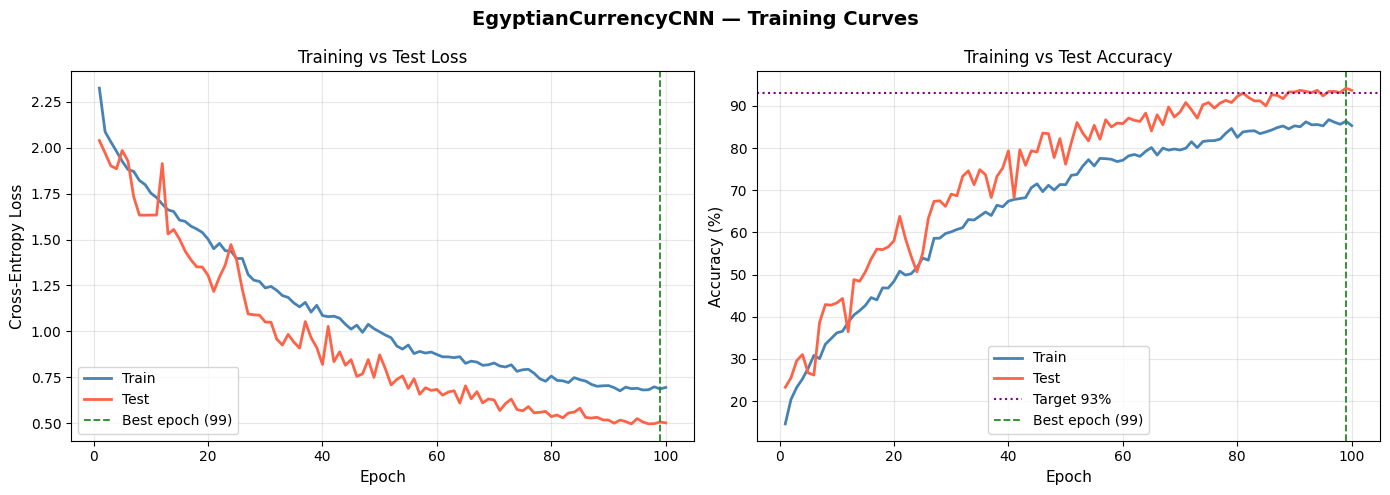

In [7]:
epochs_x = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_x, history['train_loss'], lw=2, color='steelblue', label='Train')
ax1.plot(epochs_x, history['test_loss'],  lw=2, color='tomato',    label='Test')
ax1.axvline(best_epoch, ls='--', lw=1.3, color='forestgreen', label=f'Best epoch ({best_epoch})')
ax1.set_xlabel('Epoch', fontsize=11); ax1.set_ylabel('Cross-Entropy Loss', fontsize=11)
ax1.set_title('Training vs Test Loss', fontsize=12)
ax1.legend(fontsize=10); ax1.grid(alpha=0.3)

ax2.plot(epochs_x, [a*100 for a in history['train_acc']], lw=2, color='steelblue', label='Train')
ax2.plot(epochs_x, [a*100 for a in history['test_acc']],  lw=2, color='tomato',    label='Test')
ax2.axhline(93, ls=':', lw=1.5, color='purple', label='Target 93%')
ax2.axvline(best_epoch, ls='--', lw=1.3, color='forestgreen', label=f'Best epoch ({best_epoch})')
ax2.set_xlabel('Epoch', fontsize=11); ax2.set_ylabel('Accuracy (%)', fontsize=11)
ax2.set_title('Training vs Test Accuracy', fontsize=12)
ax2.legend(fontsize=10); ax2.grid(alpha=0.3)

plt.suptitle('EgyptianCurrencyCNN — Training Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 7. Evaluation on Test Set


In [8]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()
print(f'Loaded: {CKPT_PATH}')

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        logits = model(imgs)
        probs  = F.softmax(logits, dim=1)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

test_acc = accuracy_score(all_labels, all_preds)
print(f'\nTest Accuracy : {test_acc*100:.2f}%')
print(f'Target (93%)  : {"MET ✓" if test_acc >= 0.93 else "NOT MET"}')
print('\n' + '─'*65)
print(classification_report(all_labels, all_preds,
                             target_names=ORDERED_LABELS, digits=4))


Loaded: best_model.pth

Test Accuracy : 94.21%
Target (93%)  : MET ✓

─────────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

       1 EGP     1.0000    0.9500    0.9744        20
10 EGP (old)     0.9054    0.8375    0.8701        80
     100 EGP     0.9302    1.0000    0.9639        80
10 EGP (new)     0.9474    0.9692    0.9582       130
20 EGP (old)     0.9359    0.9125    0.9241        80
     200 EGP     0.9740    0.9375    0.9554        80
20 EGP (new)     0.9695    0.9769    0.9732       130
       5 EGP     0.9048    0.9500    0.9268        80
      50 EGP     0.9359    0.9125    0.9241        80

    accuracy                         0.9421       760
   macro avg     0.9448    0.9385    0.9411       760
weighted avg     0.9422    0.9421    0.9417       760



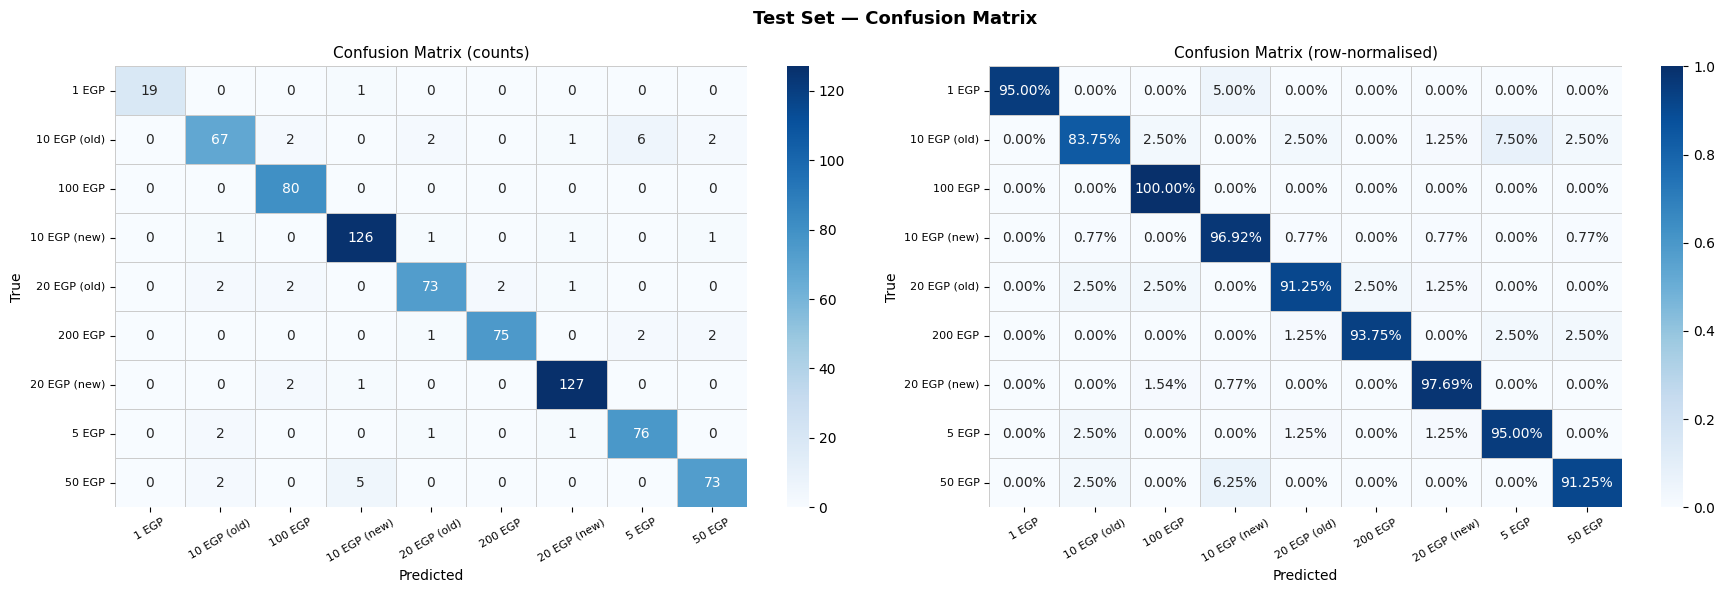

In [9]:
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm], ['d', '.2%'],
    ['Confusion Matrix (counts)', 'Confusion Matrix (row-normalised)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=ORDERED_LABELS, yticklabels=ORDERED_LABELS,
                linewidths=0.4, linecolor='#ccc')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True',      fontsize=10)
    ax.set_title(title,        fontsize=11)
    ax.tick_params(axis='x', labelrotation=30, labelsize=8)
    ax.tick_params(axis='y', labelrotation=0,  labelsize=8)

plt.suptitle('Test Set — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()    

---
## 8. Predictions on Unseen Test Images

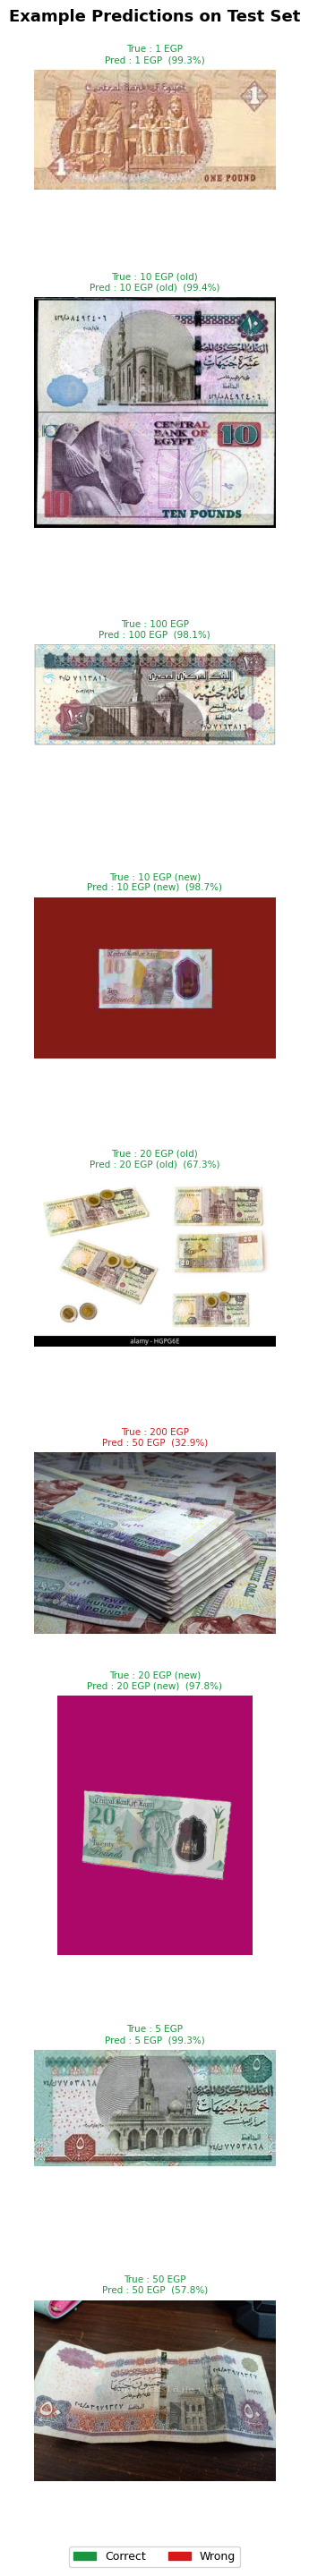

In [13]:
def show_predictions(n_per_class: int = 1):
    model.eval()

    by_class = {i: [] for i in range(NUM_CLASSES)}
    for img_path, label_idx in test_ds.samples:
        if len(by_class[label_idx]) < n_per_class:
            by_class[label_idx].append(img_path)
        if all(len(v) >= n_per_class for v in by_class.values()):
            break

    fig, axes = plt.subplots(NUM_CLASSES, n_per_class,
                              figsize=(n_per_class * 3.0, NUM_CLASSES * 3.2))
    if n_per_class == 1:
        axes = axes.reshape(-1, 1)

    for r in range(NUM_CLASSES):
        for c in range(n_per_class):
            ax = axes[r][c]
            if c >= len(by_class[r]):
                ax.axis('off'); continue
            pil = PILImage.open(by_class[r][c]).convert('RGB')
            t   = eval_tf(pil).unsqueeze(0)
            with torch.no_grad():
                prob = F.softmax(model(t), dim=1)[0].cpu().numpy()
            pred_idx   = int(prob.argmax())
            conf       = prob[pred_idx]
            colour     = '#1a9641' if pred_idx == r else '#d7191c'
            ax.imshow(pil)
            ax.set_title(
                f'True : {ORDERED_LABELS[r]}\n'
                f'Pred : {ORDERED_LABELS[pred_idx]}  ({conf*100:.1f}%)',
                color=colour, fontsize=7.5
            )
            for spine in ax.spines.values():
                spine.set_edgecolor(colour); spine.set_linewidth(3.5)
            ax.axis('off')

    fig.legend(
        handles=[
            mpatches.Patch(color='#1a9641', label='Correct'),
            mpatches.Patch(color='#d7191c', label='Wrong'),
        ],
        loc='lower center', ncol=2, fontsize=9, bbox_to_anchor=(0.5, -0.015)
    )
    plt.suptitle('Example Predictions on Test Set', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()   


show_predictions(n_per_class=1)